In [10]:
import math
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from genkit._noise import sample_scaled_isotropic_alpha_stable
from genkit.diffusion import DDPMV, DLPMEps
from genkit.metrics import mmd_rbf
from genkit.nn import MLPModel
from genkit.training import train


COLORS = {"DDPM": "#2f6fbb", "DLPM": "#d9792b", "DLPM + clip": "#b85b1a"}
DEVICE = torch.device("cpu")
DTYPE = torch.float32
SEED = 0

ALPHA = 1.7
DIM = 100
N_TRAIN = 10_000
N_TEST = N_MMD = 2_000
SAMPLE_CHUNK_SIZE = 500
BASELINE_NAME = "test-vs-test"

N_REVERSE_STEPS = 64
DDPM_N_STEPS = N_REVERSE_STEPS
DLPM_N_STEPS = N_REVERSE_STEPS + 1  # DLPM's native sampler runs n_steps - 1 reverse updates.
DDPM_SIGMA_MAX = 5.0

N_EPOCHS = 128
BATCH_SIZE = 256
LR = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = None
DLPM_CLIP_NORM = 1.0
DEPTH = 3
WIDTH = 128
TIME_DIM = 64

TRAIN_KWARGS = dict(
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    lr=LR,
    device=DEVICE,
    use_adamw=True,
    weight_decay=WEIGHT_DECAY,
    grad_clip_norm=GRAD_CLIP_NORM,
    lr_schedule="cosine",
    cosine_eta_min_ratio=0.05,
    stats_freq_epochs=1,
    log_grad_norm=True,
    freq_logging=0,
)


In [11]:
def sample_alpha_stable(n_samples):
    return sample_scaled_isotropic_alpha_stable(n_samples, dim=DIM, alpha=ALPHA, device=DEVICE, dtype=DTYPE)


def make_net():
    return MLPModel(input_dim=DIM, output_dim=DIM, width=WIDTH, depth=DEPTH, time_dim=TIME_DIM).to(device=DEVICE, dtype=DTYPE)


def set_seed(seed):
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))


def train_one(name, model, x_train, seed, train_kwargs=None):
    train_kwargs = TRAIN_KWARGS if train_kwargs is None else train_kwargs
    set_seed(seed)
    start = time.time()
    model, info = train(model, x_train, **train_kwargs)
    seconds = time.time() - start

    stats = pd.DataFrame(info["stats"])
    stats.insert(0, "model", name)
    batch_size = int(info["train_config"]["batch_size"])
    stats["global_step"] = stats["epoch"] * math.ceil(len(x_train) / batch_size)
    stats["train_seconds"] = seconds
    stats["loss_tag"] = getattr(model, "_loss_tag", None)
    return model, info, stats


@torch.no_grad()
def evaluate_samples(name, x_ref, x_gen):
    x_ref = x_ref.detach().cpu().to(torch.float64)
    x_gen = x_gen.detach().cpu().to(torch.float64)
    return {"model": name, "mmd_rbf": mmd_rbf(x_ref[:N_MMD], x_gen[:N_MMD])}


def evaluate_sampler(name, sample_fn, x_test, seed):
    set_seed(seed)
    chunks = []
    for start in range(0, len(x_test), SAMPLE_CHUNK_SIZE):
        size = min(SAMPLE_CHUNK_SIZE, len(x_test) - start)
        chunks.append(sample_fn(size).detach().cpu())
    return evaluate_samples(name, x_test, torch.cat(chunks, dim=0))


In [12]:
set_seed(SEED)
x_train = sample_alpha_stable(N_TRAIN)
x_test = sample_alpha_stable(N_TEST)

set_seed(SEED + 1)
ddpm = DDPMV(net=make_net(), dim=DIM, n_steps=DDPM_N_STEPS, sigma_max=DDPM_SIGMA_MAX, sampler="ddpm", device=DEVICE, fdtype=DTYPE)
set_seed(SEED + 1)
dlpm = DLPMEps(net=make_net(), dim=DIM, n_steps=DLPM_N_STEPS, alpha=ALPHA, device=DEVICE, fdtype=DTYPE)
set_seed(SEED + 1)
dlpm_clip = DLPMEps(net=make_net(), dim=DIM, n_steps=DLPM_N_STEPS, alpha=ALPHA, device=DEVICE, fdtype=DTYPE)

ddpm, ddpm_info, ddpm_stats = train_one("DDPM", ddpm, x_train, seed=SEED + 11)
dlpm, dlpm_info, dlpm_stats = train_one("DLPM", dlpm, x_train, seed=SEED + 11)
dlpm_clip, dlpm_clip_info, dlpm_clip_stats = train_one("DLPM + clip", dlpm_clip, x_train, seed=SEED + 11, train_kwargs=dict(TRAIN_KWARGS, grad_clip_norm=DLPM_CLIP_NORM))

train_stats = pd.concat([ddpm_stats, dlpm_stats, dlpm_clip_stats], ignore_index=True)
train_configs = pd.DataFrame([
    {"model": "DDPM", **ddpm_info["train_config"]},
    {"model": "DLPM", **dlpm_info["train_config"]},
    {"model": "DLPM + clip", **dlpm_clip_info["train_config"]},
])


In [13]:
train_summary = train_stats.groupby("model", sort=False).agg(
    epochs=("epoch", "max"),
    global_steps=("global_step", "max"),
    final_loss=("training_loss", "last"),
    best_loss=("training_loss", "min"),
    final_grad_norm=("grad_norm", "last"),
    max_grad_norm=("grad_norm", "max"),
    train_seconds=("train_seconds", "first"),
    loss_tag=("loss_tag", "first"),
).reset_index()


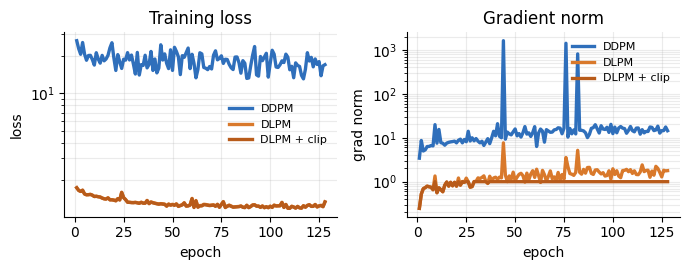

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))

for model in ["DDPM", "DLPM", "DLPM + clip"]:
    stats = train_stats[train_stats["model"] == model]
    axes[0].plot(stats["epoch"], stats["training_loss"], color=COLORS[model], linewidth=2.4, label=model)
    axes[1].plot(stats["epoch"], stats["grad_norm"], color=COLORS[model], linewidth=2.4, label=model)

axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_yscale("log")

axes[1].set_title("Gradient norm")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("grad norm")
axes[1].set_yscale("log")

for ax in axes:
    ax.grid(axis="both", which="both", alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()


In [17]:
metric_rows = [
    evaluate_sampler("DDPM", ddpm.sample, x_test, seed=SEED + 101),
    evaluate_sampler("DLPM", dlpm.sample, x_test, seed=SEED + 102),
    evaluate_sampler("DLPM + clip", dlpm_clip.sample, x_test, seed=SEED + 102),
    evaluate_samples(BASELINE_NAME, x_test, sample_alpha_stable(len(x_test))),
]
final_metrics = pd.DataFrame(metric_rows)
final_table = final_metrics.merge(
    train_summary[["model", "final_loss", "final_grad_norm", "max_grad_norm"]],
    on="model",
    how="left",
).merge(train_configs[["model", "grad_clip_norm"]], on="model", how="left")
final_table = final_table[["model", "grad_clip_norm", "final_loss", "final_grad_norm", "max_grad_norm", "mmd_rbf"]]


def fmt_optional(value):
    return "NA" if pd.isna(value) else f"{value:.3e}"


def fmt_clip(value):
    return "NA" if pd.isna(value) else f"{value:g}"


lines = [
    f"**d = {DIM}; n_train = {N_TRAIN:,}; epochs = {N_EPOCHS}**",
    "",
    "| model | grad-clip | final-loss | final-grad-norm | max-grad-norm | MMD-RBF |",
    "|---|---:|---:|---:|---:|---:|",
]
for row in final_table.itertuples(index=False):
    lines.append(
        f"| {row.model} | {fmt_clip(row.grad_clip_norm)} | {fmt_optional(row.final_loss)} | "
        f"{fmt_optional(row.final_grad_norm)} | {fmt_optional(row.max_grad_norm)} | {row.mmd_rbf:.3e} |"
    )

table = "\n".join(lines)
print(table)
display(Markdown(table))


**d = 100; n_train = 10,000; epochs = 128**

| model | grad-clip | final-loss | final-grad-norm | max-grad-norm | MMD-RBF |
|---|---:|---:|---:|---:|---:|
| DDPM | NA | 1.697e+01 | 1.442e+01 | 1.607e+03 | 4.321e-02 |
| DLPM | NA | 1.346e+00 | 1.782e+00 | 7.635e+00 | 2.366e-01 |
| DLPM + clip | 1 | 1.342e+00 | 1.000e+00 | 1.000e+00 | 2.288e-01 |
| test-vs-test | NA | NA | NA | NA | 5.433e-04 |


**d = 100; n_train = 10,000; epochs = 128**

| model | grad-clip | final-loss | final-grad-norm | max-grad-norm | MMD-RBF |
|---|---:|---:|---:|---:|---:|
| DDPM | NA | 1.697e+01 | 1.442e+01 | 1.607e+03 | 4.321e-02 |
| DLPM | NA | 1.346e+00 | 1.782e+00 | 7.635e+00 | 2.366e-01 |
| DLPM + clip | 1 | 1.342e+00 | 1.000e+00 | 1.000e+00 | 2.288e-01 |
| test-vs-test | NA | NA | NA | NA | 5.433e-04 |